Taking Pitch Characteristics and Applying at Count Level

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings 
warnings.filterwarnings("ignore")

# copy and pasted from v1 

df1 = pd.read_csv("combined_tm(7:13).csv", low_memory=False)

type_map = {
    'Fastball': '4-Seam', 'FourSeamFastBall': '4-Seam', 'FourSeamFastball': '4-Seam',
    'Slider': 'Slider', 'Curveball': 'Curveball', 'ChangeUp': 'Changeup',
    'Cutter': 'Cutter', 'Sinker': 'Sinker', 'Sweeper': 'Sweeper',
}

df1["PitchType"] = df1['TaggedPitchType'].map(type_map)

df1['swing'] = df1['PitchCall'].isin(['StrikeSwinging', 'FoulBallFieldable', 'InPlay', 'FoulBallNotFieldable'])
df1['whiff'] = df1['PitchCall'] == 'StrikeSwinging'

FOCUS = [ '4-Seam', 'Slider', 'Curveball', 'Changeup', 'Cutter', 'Sinker', 'Sweeper']
FEATURES = ['RelSpeed', 'InducedVertBreak', 'HorzBreak', 'SpinRate', 
'VertApprAngle', 'Extension', 'PlateLocSide', 'PlateLocHeight']

#Building count column 

df1['Count'] = df1['Balls'].astype(str) + '-' + df1['Strikes'].astype(str)

df1_swings = df1[df1['swing'] & df1['PitchType'].isin(FOCUS)].dropna(subset=FEATURES).copy()

print(df1_swings['PitchType'].value_counts())
print(df1_swings.shape)

count_pitch = df1_swings.groupby(['Count', 'PitchType']).size().unstack(fill_value=0)
print(count_pitch)

# drop 3-0 because sample is slim. Mention in report. 

print(df1['PitchCall'].value_counts())

print(df1_swings.shape[0])
print(df1[df1['PitchType'].isin(FOCUS)]['PitchCall'].count())

PitchType
4-Seam       21613
Slider        6725
Changeup      3196
Curveball     3195
Sinker        2563
Cutter        1589
Sweeper        647
Name: count, dtype: int64
(39528, 175)
PitchType  4-Seam  Changeup  Curveball  Cutter  Sinker  Slider  Sweeper
Count                                                                  
0-0          4403       585        464     324     585    1149       85
0-1          1954       503        425     189     235    1012      112
0-2          1132       270        307      88     106     588       71
1-0          2899       181        138     181     342     398       20
1-1          2136       346        404     191     280     792       86
1-2          1549       544        547     137     166     963      116
2-0          1197        56         46      65     133     119        8
2-1          1650       130        152     107     197     348       25
2-2          1782       404        480     141     204     828       82
3-0            81         

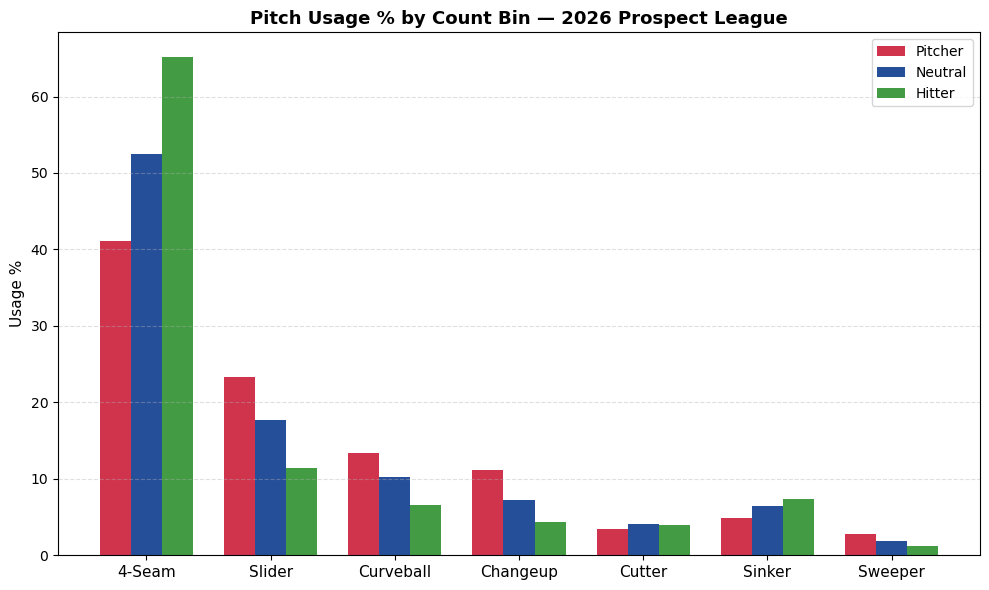

In [16]:
# Pitch usage by count bin plot 

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(FOCUS))
width = 0.25

colors = ['#C8102E', '#003087', '#228B22']
for i, (count_bin, color) in enumerate(zip(COUNT_BINS, colors)):
    vals = [usage_pct.loc[count_bin, pitch] if pitch in usage_pct.columns else 0 for pitch in FOCUS]
    ax.bar(x + i * width, vals, width, label=count_bin, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(FOCUS, fontsize=11)
ax.set_ylabel('Usage %', fontsize=11)
ax.set_title('Pitch Usage % by Count Bin — 2026 Prospect League', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('pitch_usage_by_count.png', dpi=150, bbox_inches='tight')
plt.show()

We Will group pitch counts by 3 buckets: pitcher counts, nuetral, and hitter counts. Note that 3-0 counts are dropped completely. 

In [19]:
count_bins = {
    '0-1': 'Pitcher', '0-2': 'Pitcher', '1-2': 'Pitcher',
    '0-0': 'Neutral', '1-0': 'Hitter', '1-1': 'Neutral', '2-1': 'Hitter',
    '2-0': 'Hitter',  '2-2': 'Pitcher',  '3-1': 'Hitter',  '3-2': 'Neutral',
}

df1_swings['CountBin'] = df1_swings['Count'].map(count_bins)
df1_swings = df1_swings[df1_swings['CountBin'].notna()].copy()



# Pitch usage by count bin — using full pitch dataset not swings only
usage = (df1[df1['PitchType'].isin(FOCUS) & df1['CountBin'].notna()]
         .groupby(['CountBin', 'PitchType'])
         .size()
         .unstack(fill_value=0))
usage_pct = usage.div(usage.sum(axis=1), axis=0) * 100
#print(usage_pct.round(1))

#muted for data sharing rules by trackman.

In [7]:
# Whiff rate by count bins and pitch type
whiff_by_count = (df1_swings.groupby(['CountBin', 'PitchType'])
                 .agg(swings=('whiff', 'size'), whiffs=('whiff', 'sum'))
                 .assign(whiff_pct=lambda x: (x.whiffs / x.swings * 100).round(1))
                 ['whiff_pct'].unstack())
# print(whiff_by_count)

# Muted output for data sharing rukes by trackman

In [17]:
# Logistic Regression Models for counts 
#Loops throuhgh count bins and through pitch types to build models for each combination.
# 80/20 train/test split, StandardScaler then applied to feature. 
from sklearn.model_selection import train_test_split

COUNT_BINS = ['Pitcher', 'Neutral', 'Hitter']

models   = {}
scalers  = {}
results  = {}
test_data = {}  # store test sets for evaluation cells

for count_bin in COUNT_BINS:
    models[count_bin]    = {}
    scalers[count_bin]   = {}
    results[count_bin]   = {}
    test_data[count_bin] = {}

    sub_bin = df1_swings[df1_swings['CountBin'] == count_bin]

    for pitch in FOCUS:
        sub = sub_bin[sub_bin['PitchType'] == pitch].dropna(subset=FEATURES)
        if len(sub) < 50:
            print(f"SKIP {count_bin} {pitch} - n={len(sub)}")
            continue

        X = sub[FEATURES].values
        y = sub['whiff'].values

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        scaler   = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc  = scaler.transform(X_test)

        model = LogisticRegression(max_iter=1000)
        model.fit(X_train_sc, y_train)

        auc = roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1])

        models[count_bin][pitch]    = model
        scalers[count_bin][pitch]   = scaler
        results[count_bin][pitch]   = pd.Series(model.coef_[0], index=FEATURES).rename('coef')
        test_data[count_bin][pitch] = (X_test_sc, y_test)

        print(f"{count_bin:10s} {pitch:12s} n_train={len(y_train):5d} n_test={len(y_test):4d} whiff%={y_test.mean()*100:.1f} AUC={auc:.3f}")



Pitcher    4-Seam       n_train= 5133 n_test=1284 whiff%=20.4 AUC=0.662
Pitcher    Slider       n_train= 2712 n_test= 679 whiff%=30.5 AUC=0.734
Pitcher    Curveball    n_train= 1407 n_test= 352 whiff%=25.6 AUC=0.767
Pitcher    Changeup     n_train= 1376 n_test= 345 whiff%=32.8 AUC=0.663
Pitcher    Cutter       n_train=  444 n_test= 111 whiff%=31.5 AUC=0.628
Pitcher    Sinker       n_train=  568 n_test= 143 whiff%=16.1 AUC=0.503
Pitcher    Sweeper      n_train=  304 n_test=  77 whiff%=27.3 AUC=0.670
Neutral    4-Seam       n_train= 6672 n_test=1668 whiff%=19.4 AUC=0.656
Neutral    Slider       n_train= 1901 n_test= 476 whiff%=28.6 AUC=0.740
Neutral    Curveball    n_train=  855 n_test= 214 whiff%=30.4 AUC=0.753
Neutral    Changeup     n_train=  852 n_test= 213 whiff%=32.4 AUC=0.710
Neutral    Cutter       n_train=  503 n_test= 126 whiff%=25.4 AUC=0.645
Neutral    Sinker       n_train=  845 n_test= 212 whiff%=17.0 AUC=0.516
Neutral    Sweeper      n_train=  167 n_test=  42 whiff%=42.9 AU

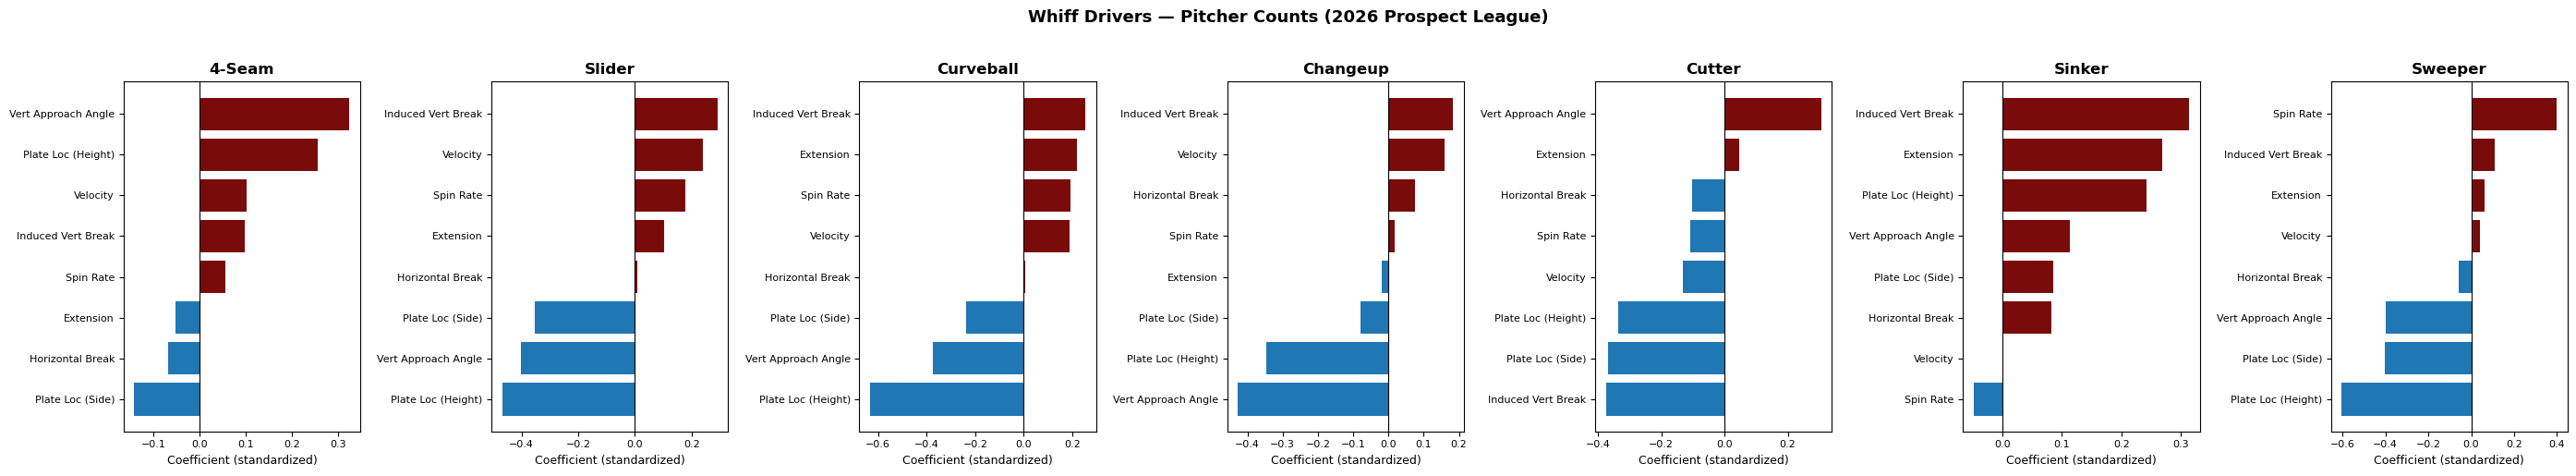

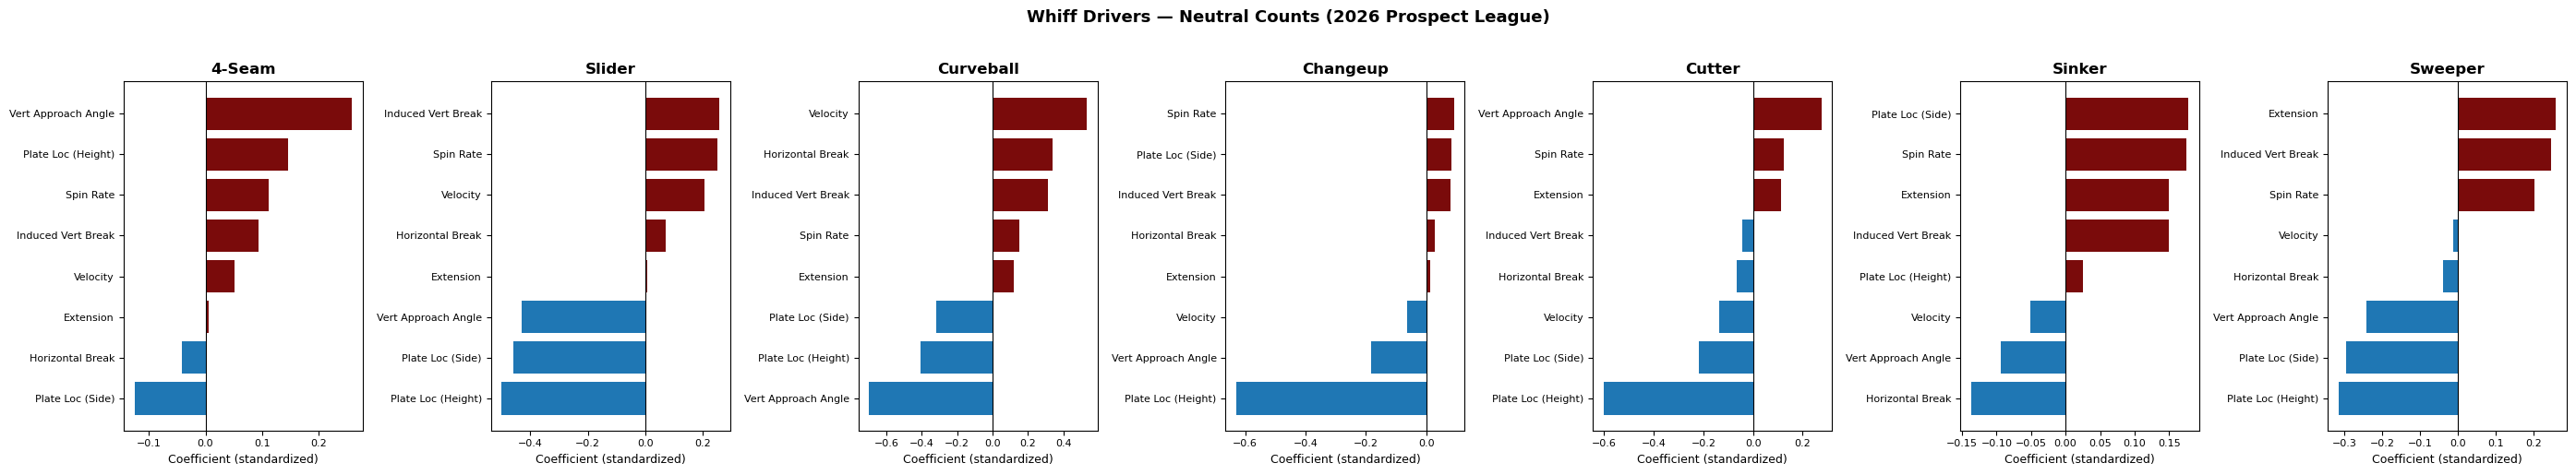

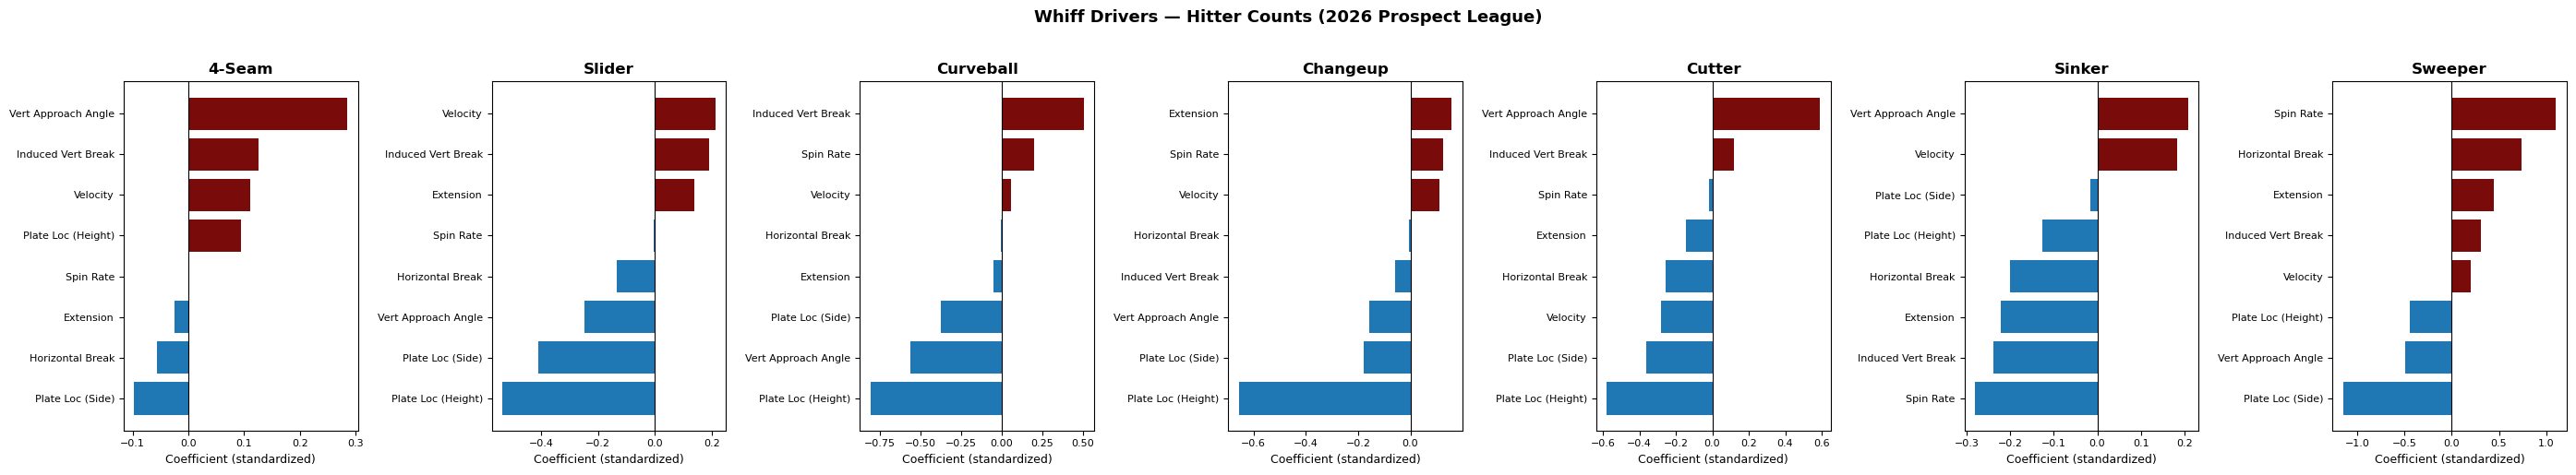

In [11]:
# Plots for coefficients, features driving whiffs by count and pitch type. Same as v1.
FEATURE_LABELS = {
    'RelSpeed':         'Velocity',
    'InducedVertBreak': 'Induced Vert Break',
    'HorzBreak':        'Horizontal Break',
    'SpinRate':         'Spin Rate',
    'VertApprAngle':    'Vert Approach Angle',
    'Extension':        'Extension',
    'PlateLocSide':     'Plate Loc (Side)',
    'PlateLocHeight':   'Plate Loc (Height)',
}

for count_bin in COUNT_BINS:
    available = [p for p in FOCUS if p in results[count_bin]]
    n = len(available)
    if n == 0:
        continue

    fig, axes = plt.subplots(1, n, figsize=(28, 5))
    if n == 1:
        axes = [axes]

    for ax, pitch in zip(axes, available):
        coefs  = results[count_bin][pitch].sort_values()
        colors = ['#7A0B0B' if c > 0 else '#1f77b4' for c in coefs]
        labels = [FEATURE_LABELS[f] for f in coefs.index]

        ax.barh(labels, coefs.values, color=colors)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(pitch, fontsize=12, fontweight='bold')
        ax.set_xlabel('Coefficient (standardized)', fontsize=9)
        ax.tick_params(labelsize=8)

    fig.suptitle(f'Whiff Drivers — {count_bin} Counts (2026 Prospect League)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'whiff_drivers_{count_bin.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
#summary of top whiff drivers by count and pitch type. Again very similar analysis as V1. 
rows = []
for count_bin in COUNT_BINS:
    for pitch in FOCUS:
        if pitch not in results[count_bin]:
            continue
        coefs = results[count_bin][pitch]
        top2  = coefs.nlargest(2).index.tolist()
        rows.append({
            'Count Bin':        count_bin,
            'Pitch Type':       pitch,
            'Top Driver':       FEATURE_LABELS[top2[0]],
            '2nd Driver':       FEATURE_LABELS[top2[1]],
        })

summary = pd.DataFrame(rows).set_index(['Count Bin','Pitch Type'])
print(summary.to_string())

                               Top Driver          2nd Driver
Count Bin Pitch Type                                         
Pitcher   4-Seam      Vert Approach Angle  Plate Loc (Height)
          Slider       Induced Vert Break            Velocity
          Curveball    Induced Vert Break           Extension
          Changeup     Induced Vert Break            Velocity
          Cutter      Vert Approach Angle           Extension
          Sinker       Induced Vert Break           Extension
          Sweeper               Spin Rate  Induced Vert Break
Neutral   4-Seam      Vert Approach Angle  Plate Loc (Height)
          Slider       Induced Vert Break           Spin Rate
          Curveball              Velocity    Horizontal Break
          Changeup              Spin Rate    Plate Loc (Side)
          Cutter      Vert Approach Angle           Spin Rate
          Sinker         Plate Loc (Side)           Spin Rate
          Sweeper               Extension  Induced Vert Break
Hitter  

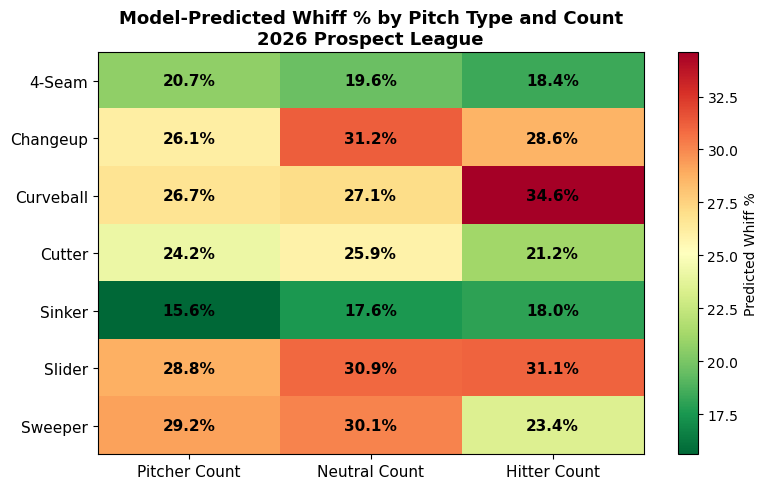

Count Bin   Pitcher  Neutral  Hitter
Pitch Type                          
4-Seam         20.7     19.6    18.4
Changeup       26.1     31.2    28.6
Curveball      26.7     27.1    34.6
Cutter         24.2     25.9    21.2
Sinker         15.6     17.6    18.0
Slider         28.8     30.9    31.1
Sweeper        29.2     30.1    23.4


In [ ]:
# Predicted whiff probability at mean features for each pitch/count bin combination

rows = []

for count_bin in COUNT_BINS:
    for pitch in FOCUS:
        if pitch not in models[count_bin]:
            continue

        sub = df1_swings[
            (df1_swings['CountBin'] == count_bin) &
            (df1_swings['PitchType'] == pitch)
        ].dropna(subset=FEATURES)

        # Hold all features at their mean for this pitch/count combo
        mean_features = sub[FEATURES].mean().values.reshape(1, -1)
        mean_scaled   = scalers[count_bin][pitch].transform(mean_features)
        pred_prob     = models[count_bin][pitch].predict_proba(mean_scaled)[0, 1]

        rows.append({
            'Pitch Type': pitch,
            'Count Bin':  count_bin,
            'Pred Whiff%': round(pred_prob * 100, 1)
        })

pred_df = pd.DataFrame(rows).pivot(index='Pitch Type', columns='Count Bin', values='Pred Whiff%')
pred_df = pred_df[['Pitcher', 'Neutral', 'Hitter']]  # order columns

# Heatmap
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pred_df.values, cmap='RdYlGn_r', aspect='auto')

ax.set_xticks(range(3))
ax.set_xticklabels(['Pitcher Count', 'Neutral Count', 'Hitter Count'], fontsize=11)
ax.set_yticks(range(len(pred_df)))
ax.set_yticklabels(pred_df.index, fontsize=11)

# Annotate cells
for i in range(len(pred_df)):
    for j in range(3):
        ax.text(j, i, f"{pred_df.values[i, j]:.1f}%",
                ha='center', va='center', fontsize=11, fontweight='bold', color='black')

plt.colorbar(im, ax=ax, label='Predicted Whiff %')
ax.set_title('Model-Predicted Whiff % by Pitch Type and Count\n2026 Prospect League',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('predicted_whiff_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(pred_df)

Model Evaluations. 
We first evaluate using the actual whiff rates taken from the data for each pitch and compare them to the whiff probability that the model outputs. 
Second, we check the model calibration curves. 
Last, we just output a visual representation of the ROC, Area under the ROC Curve. 

Count Bin Pitch Type  Predicted  Actual  Diff
  Pitcher     4-Seam       22.2    20.4   1.7
  Pitcher     Slider       32.2    30.5   1.7
  Pitcher  Curveball       30.1    25.6   4.6
  Pitcher   Changeup       28.6    32.8  -4.2
  Pitcher     Cutter       25.0    31.5  -6.5
  Pitcher     Sinker       17.2    16.1   1.1
  Pitcher    Sweeper       32.9    27.3   5.7
  Neutral     4-Seam       20.6    19.4   1.2
  Neutral     Slider       32.7    28.6   4.2
  Neutral  Curveball       30.9    30.4   0.5
  Neutral   Changeup       32.3    32.4  -0.1
  Neutral     Cutter       28.1    25.4   2.7
  Neutral     Sinker       18.7    17.0   1.7
  Neutral    Sweeper       32.7    42.9 -10.2
   Hitter     4-Seam       19.0    20.1  -1.1
   Hitter     Slider       34.2    34.6  -0.4
   Hitter  Curveball       37.5    43.2  -5.7
   Hitter   Changeup       29.3    31.7  -2.4
   Hitter     Cutter       23.5    27.2  -3.7
   Hitter     Sinker       18.9    19.6  -0.7
   Hitter    Sweeper       23.6   

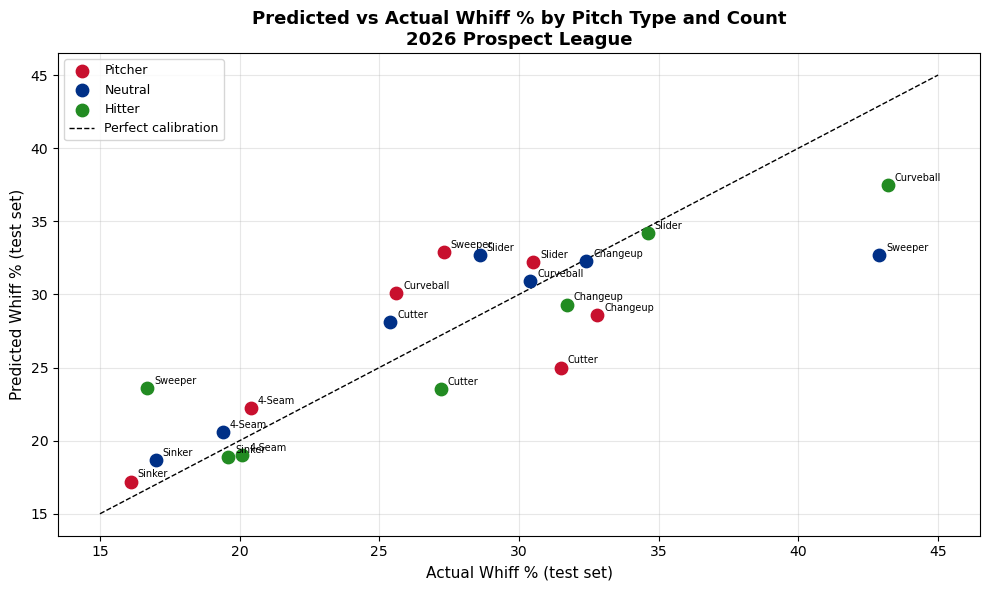

In [18]:
# Validating model predictions against actual whiff rates for only the test set

from sklearn.calibration import calibration_curve

rows = []
for count_bin in COUNT_BINS:
    for pitch in FOCUS:
        if pitch not in models[count_bin]:
            continue

        X_sc, y_test = test_data[count_bin][pitch]
        pred = models[count_bin][pitch].predict_proba(X_sc)[:, 1].mean()
        actual = y_test.mean()

        rows.append({
            'Count Bin': count_bin,
            'Pitch Type': pitch,
            'Predicted': round(pred * 100, 1),
            'Actual': round(actual * 100, 1),
            'Diff': round((pred - actual) * 100, 1)
        })

eval_df = pd.DataFrame(rows)
print(eval_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
for count_bin, color in zip(COUNT_BINS, ['#C8102E', '#003087', '#228B22']):
    sub = eval_df[eval_df['Count Bin'] == count_bin]
    ax.scatter(sub['Actual'], sub['Predicted'], label=count_bin, color=color, s=80, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(row['Pitch Type'], (row['Actual'], row['Predicted']),
                    textcoords='offset points', xytext=(5, 3), fontsize=7)

ax.plot([15, 45], [15, 45], 'k--', linewidth=1, label='Perfect calibration')
ax.set_xlabel('Actual Whiff % (test set)', fontsize=11)
ax.set_ylabel('Predicted Whiff % (test set)', fontsize=11)
ax.set_title('Predicted vs Actual Whiff % by Pitch Type and Count\n2026 Prospect League',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

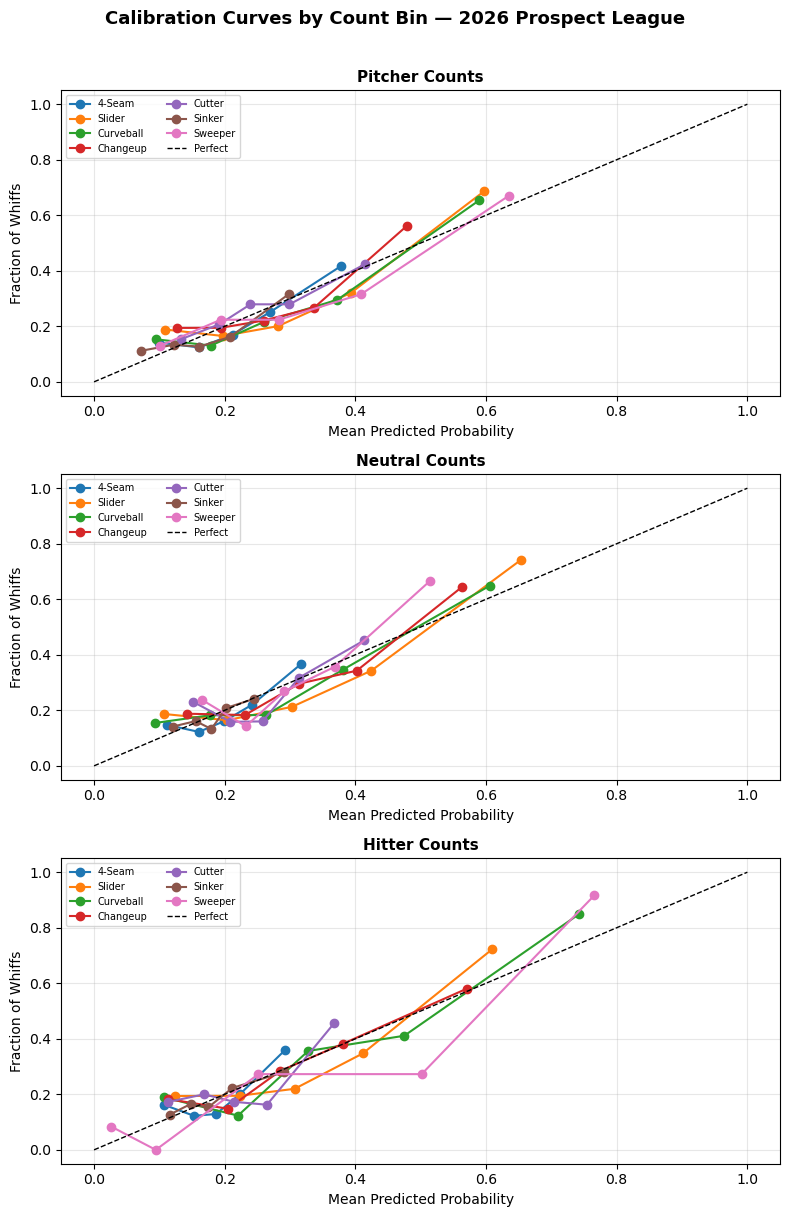

In [ ]:
#calibration curves for each count bin and pitch type combination.
# easy to see the lower sample sizes, especially for the Hitter count bin with the breaking balls.

from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(3, 1, figsize=(8, 12))

for ax, count_bin in zip(axes, COUNT_BINS):
    for pitch in FOCUS:
        if pitch not in models[count_bin]:
            continue
        sub = df1_swings[
            (df1_swings['CountBin'] == count_bin) &
            (df1_swings['PitchType'] == pitch)
        ].dropna(subset=FEATURES)

        X_sc = scalers[count_bin][pitch].transform(sub[FEATURES].values)
        probs = models[count_bin][pitch].predict_proba(X_sc)[:, 1]
        y = sub['whiff'].values

        prob_true, prob_pred = calibration_curve(y, probs, n_bins=5, strategy='quantile')
        ax.plot(prob_pred, prob_true, marker='o', label=pitch, linewidth=1.5)

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect')
    ax.set_title(f'{count_bin} Counts', fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Whiffs')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.3)

fig.suptitle('Calibration Curves by Count Bin — 2026 Prospect League',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()

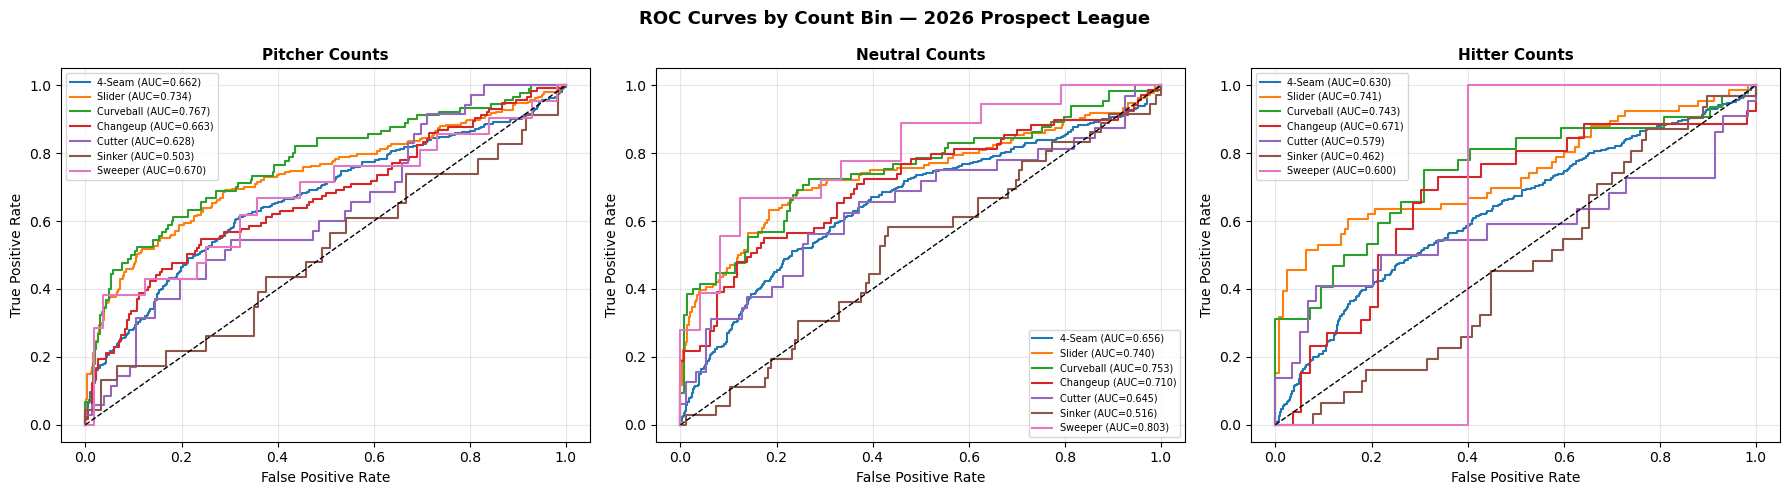

In [ ]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, count_bin in zip(axes, COUNT_BINS):
    for pitch in FOCUS:
        if pitch not in models[count_bin]:
            continue
        sub = df1_swings[
            (df1_swings['CountBin'] == count_bin) &
            (df1_swings['PitchType'] == pitch)
        ].dropna(subset=FEATURES)

        X_sc, y = test_data[count_bin][pitch]
        probs = models[count_bin][pitch].predict_proba(X_sc)[:, 1]

        fpr, tpr, _ = roc_curve(y, probs)
        auc = roc_auc_score(y, probs)
        ax.plot(fpr, tpr, label=f'{pitch} (AUC={auc:.3f})', linewidth=1.5)

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_title(f'{count_bin} Counts', fontsize=11, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

fig.suptitle('ROC Curves by Count Bin — 2026 Prospect League',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

KeyError: 'AUC'

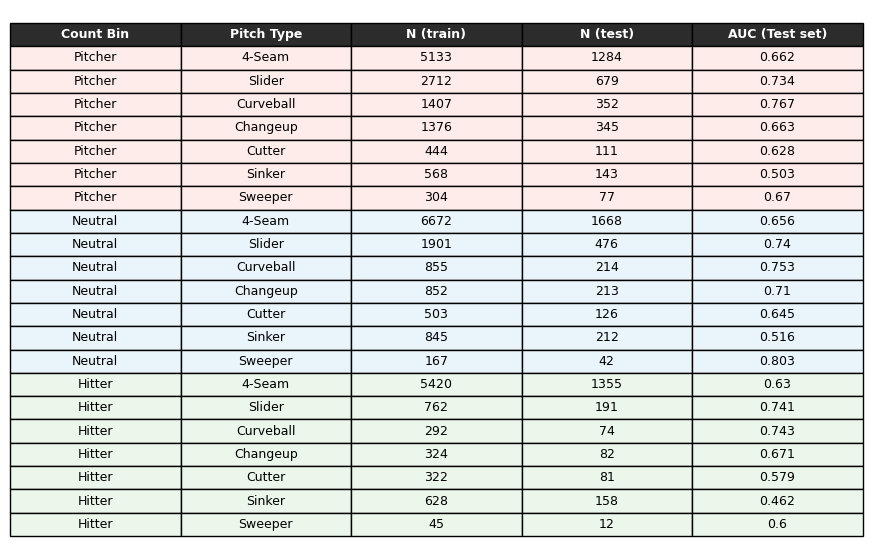

In [8]:
#Using claude to make the table output from cell 5 more presentable for the article. 


import matplotlib.pyplot as plt

auc_data = {
    'Count Bin':  ['Pitcher']*7 + ['Neutral']*7 + ['Hitter']*7,
    'Pitch Type': ['4-Seam','Slider','Curveball','Changeup','Cutter','Sinker','Sweeper']*3,
    'N (train)':  [5133,2712,1407,1376,444,568,304, 6672,1901,855,852,503,845,167, 5420,762,292,324,322,628,45],
    'N (test)':   [1284,679,352,345,111,143,77, 1668,476,214,213,126,212,42, 1355,191,74,82,81,158,12],
    'AUC (Test set)':        [0.662,0.734,0.767,0.663,0.628,0.503,0.670,
                   0.656,0.740,0.753,0.710,0.645,0.516,0.803,
                   0.630,0.741,0.743,0.671,0.579,0.462,0.600],
}

auc_df = pd.DataFrame(auc_data)

fig, ax = plt.subplots(figsize=(11, 7))
ax.axis('off')

table = ax.table(
    cellText=auc_df.values,
    colLabels=auc_df.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

# Header styling
for j in range(len(auc_df.columns)):
    table[0, j].set_facecolor('#2C2C2C')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Row shading by count bin
colors = {'Pitcher': '#FDECEA', 'Neutral': '#EAF4FB', 'Hitter': '#EAF7EA'}
for i, row in enumerate(auc_df['Count Bin']):
    for j in range(len(auc_df.columns)):
        table[i+1, j].set_facecolor(colors[row])

# Flag low AUC cells
for i, auc in enumerate(auc_df['AUC']):
    if auc < 0.55:
        table[i+1, 4].set_facecolor('#FF9999')
        table[i+1, 4].set_text_props(fontweight='bold')

plt.title('Model Performance by Pitch Type and Count Bin — 2026 Prospect League',
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('auc_table.png', dpi=150, bbox_inches='tight')
plt.show()